In [5]:
pip install GEOparse


   ---------------------------------------- 0/2 [tqdm]
   ---------------------------------------- 0/2 [tqdm]
   ---------------------------------------- 0/2 [tqdm]
   ---------------------------------------- 0/2 [tqdm]
   ---------------------------------------- 0/2 [tqdm]
   -------------------- ------------------- 1/2 [GEOparse]
   ---------------------------------------- 2/2 [GEOparse]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ranam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
import GEOparse 

In [7]:
gse = GEOparse.get_GEO(geo="GSE45827", destdir="C:/Users/ranam/OneDrive/Desktop/NU/2nd semester/Machine Learning/assignment-1-data")

25-Apr-2026 03:51:19 DEBUG utils - Directory C:/Users/ranam/OneDrive/Desktop/NU/2nd semester/Machine Learning/assignment-1-data already exists. Skipping.
25-Apr-2026 03:51:19 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/soft/GSE45827_family.soft.gz to C:/Users/ranam/OneDrive/Desktop/NU/2nd semester/Machine Learning/assignment-1-data\GSE45827_family.soft.gz
100%|██████████| 40.1M/40.1M [00:17<00:00, 2.40MB/s]  
25-Apr-2026 03:51:37 DEBUG downloader - Size validation passed
25-Apr-2026 03:51:37 DEBUG downloader - Moving C:\Users\ranam\AppData\Local\Temp\tmpq5hdf2si to C:\Users\ranam\OneDrive\Desktop\NU\2nd semester\Machine Learning\assignment-1-data\GSE45827_family.soft.gz
25-Apr-2026 03:51:38 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/soft/GSE45827_family.soft.gz
25-Apr-2026 03:51:38 INFO GEOparse - Parsing C:/Users/ranam/OneDrive/Desktop/NU/2nd semester/Machine Learning/assignment-1-data\GSE4

In [ ]:
# Creating expression matrix (genes x samples) 
expr = gse.pivot_samples('VALUE')

In [ ]:
# Count the number of genes (rows) & number of samples (columns)
n_samples = expr.shape
print(n_samples)

# We have 29873 genes & 155 samples

(29873, 155)


In [13]:
# Number of samples
samples_only = expr.shape[1]
print(samples_only)

155


In [14]:
genes_only = expr.shape[0]
print(genes_only)

29873


In [15]:
# View the data columns to extract the labels
print(gse.phenotype_data.columns)

Index(['title', 'geo_accession', 'status', 'submission_date',
       'last_update_date', 'type', 'channel_count', 'source_name_ch1',
       'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.diagnosis',
       'characteristics_ch1.1.tumor subtype', 'characteristics_ch1.2.batch',
       'characteristics_ch1.3.hybridation', 'molecule_ch1',
       'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1',
       'hyb_protocol', 'scan_protocol', 'data_processing', 'platform_id',
       'contact_name', 'contact_email', 'contact_phone', 'contact_fax',
       'contact_laboratory', 'contact_department', 'contact_institute',
       'contact_address', 'contact_city', 'contact_zip/postal_code',
       'contact_country', 'supplementary_file', 'series_id', 'data_row_count',
       'characteristics_ch1.0.cell line', 'characteristics_ch1.1.cell origin'],
      dtype='object')


In [17]:
# Extracting all columns that contain the word characteristics
char_cols = [col for col in gse.phenotype_data.columns if "characteristics" in col]

print(char_cols)

['characteristics_ch1.0.diagnosis', 'characteristics_ch1.1.tumor subtype', 'characteristics_ch1.2.batch', 'characteristics_ch1.3.hybridation', 'characteristics_ch1.0.cell line', 'characteristics_ch1.1.cell origin']


In [19]:
# Extract the unique labels from the columns
labels = set()

for col in char_cols:
    values = gse.phenotype_data[col].dropna().astype(str)
    
    for v in values:
        labels.add(v.strip())

print("Available labels:")
print(labels)

Available labels:
{'Luminal A', 'MDA-MB-436', 'MDA-MB-468', 'MDA-MB-157', 'Luminal B', 'Hs 578T', 'BT-549', 'MCF-12A', 'Basal', 'HCC70', 'HCC1187', 'Her2', 'Breast mammary gland', 'HCC1143', '184B5', '-1', 'Breast carcinoma', 'N/A', '4', '10', '3', 'MDA-MB-231', 'Breast cancer', 'BT20', '2', 'HCC38', '8', 'None (normal)', '5', '1', '9', 'HCC1937'}


In [20]:
# I need to find the right column that contains my data
for col in gse.phenotype_data.columns:
    print("\n", col)
    print(gse.phenotype_data[col].dropna().unique()[:10])


 title
['Basal Sample1 rep1' 'Basal Sample2 rep1-2' 'Her2 Sample3 rep1'
 'Basal Sample4 rep1-2' 'Her2 Sample5 rep1-2' 'Her2 Sample6 rep1-2'
 'Basal Sample7 rep1' 'Basal Sample8 rep1-2' 'Basal Sample9 rep1'
 'Basal Sample10 rep1-2']

 geo_accession
['GSM1116084' 'GSM1116085' 'GSM1116086' 'GSM1116087' 'GSM1116088'
 'GSM1116089' 'GSM1116090' 'GSM1116091' 'GSM1116092' 'GSM1116093']

 status
['Public on Mar 24 2016']

 submission_date
['Apr 05 2013']

 last_update_date
['Mar 24 2016']

 type
['RNA']

 channel_count
['1']

 source_name_ch1
['Human Basal Tumor Sample' 'Human Her2 Tumor Sample' 'Human CellLine'
 'Human Normal' 'Human Luminal A Tumor Sample'
 'Human Luminal B Tumor Sample']

 organism_ch1
['Homo sapiens']

 taxid_ch1
['9606']

 characteristics_ch1.0.diagnosis
['Breast cancer' 'None (normal)']

 characteristics_ch1.1.tumor subtype
['Basal' 'Her2' 'N/A' 'Luminal A' 'Luminal B']

 characteristics_ch1.2.batch
['8' '9' '10' '2' '5' '1' '4' '3']

 characteristics_ch1.3.hybridation
[

In [ ]:
# The column that contains my data is source_name_ch1
# To get the labels
labels = set(
    gse.phenotype_data['source_name_ch1']
    .dropna()
    .astype(str)
    .str.strip()
)
labels.discard("N/A")
print(labels)

# I have 4 tumor subtypes + the normal
# 'Luminal A', 'Basal', 'Luminal B', 'Her2, Human CellLine, Human Normal'

{'Human Luminal A Tumor Sample', 'Human Basal Tumor Sample', 'Human Her2 Tumor Sample', 'Human CellLine', 'Human Normal', 'Human Luminal B Tumor Sample'}


# I loaded the data, then I created a gene expression matrix where the rows were the genes and the columns were the samples. The total number of samples we had was 155, and the total number of genes was 29,873. To extract the labels, I first viewed the names of the columns, and then I extracted the columns that contained the word characteristics to know exactly which column my labels were in. I extracted the unique labels from the columns, and then, to find the right column, I printed the first 10 values in each column, and I determined the column of interest, which was characteristics_ch1.1.tumor subtype. Then I printed the labels, which were luminal A, basal, luminal B, and HER2, in addition to Human CellLine and Human Normal

In [47]:
# To know the top variable genes, I will compute gene-wise variance across samples and rank them
# For each gene, I will look across all samples and compute how much it varies (axis=1).
gene_variance = expr.var(axis=1)
top_genes = gene_variance.sort_values(ascending=False).head(50)

print(top_genes)

ID_REF
206378_at       23.590825
1553602_at      22.656410
202917_s_at     20.718154
209173_at       20.552853
228241_at       20.149288
206509_at       20.134270
205916_at       19.734115
214451_at       18.116456
237339_at       17.870538
205225_at       17.795412
205044_at       17.227131
205009_at       17.210535
223864_at       17.139079
206799_at       16.953213
202018_s_at     16.527565
203757_s_at     16.137513
220414_at       16.112006
229152_at       15.210951
214079_at       15.145517
202037_s_at     14.928963
217022_s_at     14.824598
211430_s_at     14.727105
204304_s_at     14.238104
209351_at       14.188359
214677_x_at     13.716874
203980_at       13.593794
211657_at       13.569909
37892_at        13.494229
217148_x_at     13.238555
203915_at       13.097880
204351_at       13.018476
206754_s_at     12.987490
204623_at       12.896347
227742_at       12.858245
226197_at       12.564291
226192_at       12.551902
242579_at       12.534211
237395_at       12.528232
20447

# I computed the gene-wise variance across the samples and ranked them. So, for each gene, I looked across all samples and computed how much it varied. I arranged them, and I printed the top 50 genes.

In [48]:
# To Subset the dataset to the selected genes 
expr_top = expr.loc[top_genes.index]
print(expr_top)

name          GSM1116084  GSM1116085  GSM1116086  GSM1116087  GSM1116088  \
ID_REF                                                                     
206378_at       1.027550    0.996334    13.08150    0.895951    13.08930   
1553602_at      0.438811    0.520444     8.35960    0.055358    12.87930   
202917_s_at    12.125300   11.919500     8.49786    7.259910    14.74400   
209173_at       1.372720    4.505090    11.67830    1.203420    12.93110   
228241_at       1.807300    1.828450     1.83649    1.838230     8.84976   
206509_at       2.435260    2.344530     8.46790    2.439360    13.78590   
205916_at       6.179390    5.572710     1.68422    1.144380    14.19180   
214451_at       1.714620    1.754850    11.14180    1.757060    12.50430   
237339_at       0.987617    1.050590     7.04658    1.005400     8.35196   
205225_at       3.430680    1.397940     2.88125    3.023460     2.56285   
205044_at      11.519500   14.135700     3.04083   12.318000     3.07349   
205009_at   

In [49]:
# To Standardize the data
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [50]:
# transpose because StandardScaler expects: rows = samples, columns = features
scaler = StandardScaler()

In [51]:
expr_scaled = scaler.fit_transform(expr_top.T)

# convert back to DataFrame (to keep gene names)
expr_scaled = pd.DataFrame(
    expr_scaled,
    index=expr_top.columns,
    columns=expr_top.index
).T

In [52]:
print(expr_scaled)

name          GSM1116084  GSM1116085  GSM1116086  GSM1116087  GSM1116088  \
ID_REF                                                                     
206378_at      -1.025396   -1.031844    1.464397   -1.052578    1.466008   
1553602_at     -1.183372   -1.166167    0.486097   -1.264193    1.438716   
202917_s_at     0.970412    0.925052    0.170891   -0.101965    1.547598   
209173_at      -1.515244   -0.822070    0.765318   -1.552709    1.042555   
228241_at      -1.039065   -1.034338   -1.032541   -1.032152    0.534918   
206509_at      -1.122476   -1.142762    0.226316   -1.121559    1.415327   
205916_at       0.367834    0.230823   -0.647345   -0.769262    2.177339   
214451_at      -1.021923   -1.012441    1.200111   -1.011920    1.521259   
237339_at      -1.094281   -1.079336    0.343640   -1.090061    0.653434   
205225_at      -0.770968   -1.254398   -0.901634   -0.867814   -0.977357   
205044_at       1.092272    1.724640   -0.957128    1.285279   -0.949234   
205009_at   

# Clustering and dimensionality reduction both rely on distances between the data points. If one feature ranges from 0 to 10 and another from 0 to 1,000, the large one unfairly dominates. So, I scaled the data using standard scaler, which fixes this by transforming every feature to mean equals zero and standard deviation equals one.

In [ ]:
# P;otting the Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# transpose so: rows = samples, columns = genes
data = expr_scaled.T

In [58]:
labels = gse.phenotype_data['source_name_ch1'].astype(str).str.strip()
labels.index = data.index  # align with samples

In [65]:
# Replacing sample names with group labels
data_named = data.copy()
data_named.index = labels

In [66]:
unique_labels = labels.unique()
palette = dict(zip(unique_labels, sns.color_palette("tab10", len(unique_labels))))
row_colors = labels.map(palette)

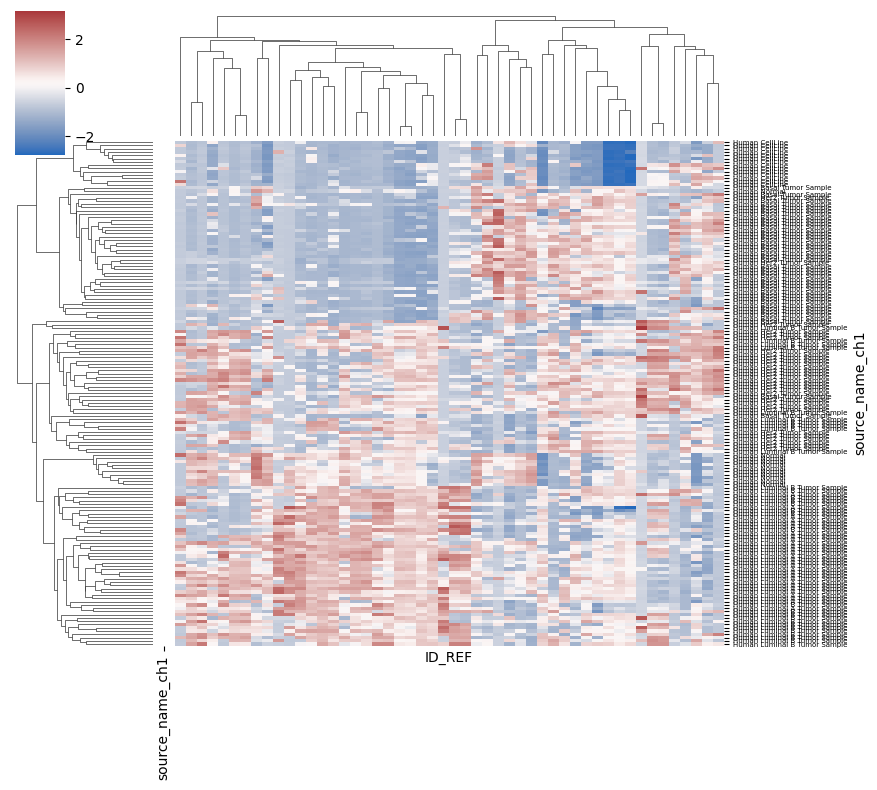

In [76]:
# Heatmap
g = sns.clustermap(
    data_named,
    row_cluster=True,
    col_cluster=True,
    row_colors=row_colors,
    cmap="vlag",
    xticklabels=False,
    yticklabels=True,   # now shows group names
    figsize=(10, 8)
)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=5)
plt.show()

# Observations do cluster by group and there are visible gene expression patterns are some genes get down-regulated as shown by the blue colors and the others are up-regulated as shown in the red color. 

In [42]:
# t-sne
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

data_tsne = tsne.fit_transform(data)

In [73]:
labels = gse.phenotype_data['source_name_ch1']

labels = (
    labels.astype(str)
    .str.strip()
    .replace("N/A", None)
)

labels = labels.reindex(data.index)

tsne_df["group"] = labels
tsne_df = tsne_df.dropna(subset=["group"])

In [74]:
# Creating dataframe for plotting
import pandas as pd

tsne_df = pd.DataFrame(
    data_tsne,
    columns=["tSNE1", "tSNE2"],
    index=data.index
)

tsne_df["group"] = labels

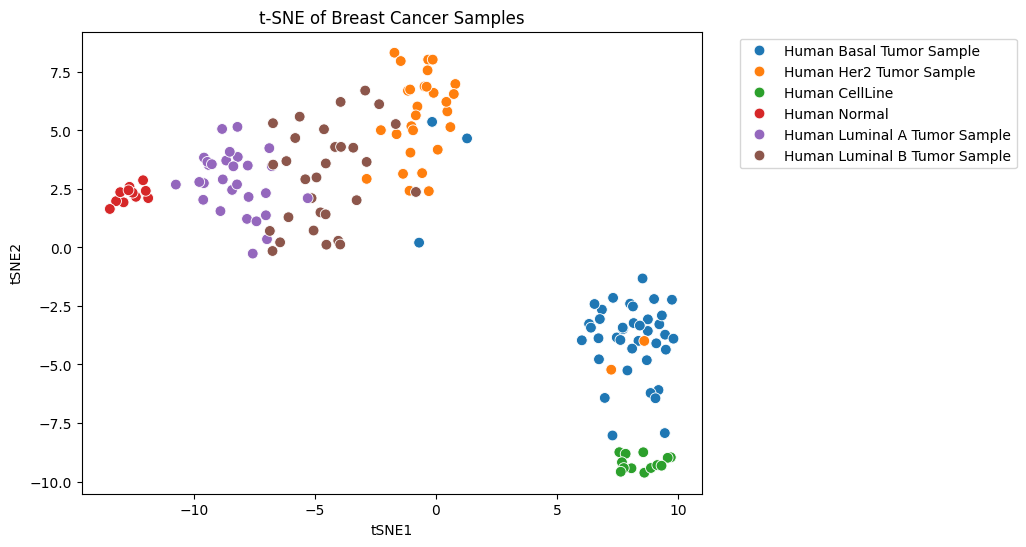

In [75]:
#Plotting t-SNE (colored by group)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=tsne_df,
    x="tSNE1",
    y="tSNE2",
    hue="group",
    palette="tab10",
    s=60
)

plt.title("t-SNE of Breast Cancer Samples")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

# The Groups are separated based on their source and it is indicated by different colors

# Do observations cluster according to biological groups?
yes observations do cluster according to biological groups each shown in different color, the easier to interpret visualization was the t-sne because there is a clear color separation between the different biological groups and it is so clear and easy to be seen based on different colors.